In [1]:
import os
import shutil

# Remove old mount
if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')

# Now mount fresh
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/MIA/7960856.zip -d /content/drive/MyDrive/MIA

Archive:  /content/drive/MyDrive/MIA/7960856.zip
   creating: /content/drive/MyDrive/MIA/7960856/
  inflating: /content/drive/MyDrive/MIA/7960856/.DS_Store  
  inflating: /content/drive/MyDrive/MIA/7960856/center_ids.xlsx  
   creating: /content/drive/MyDrive/MIA/7960856/ISLES-2022/
   creating: /content/drive/MyDrive/MIA/7960856/ISLES-2022/sub-strokecase0194/
   creating: /content/drive/MyDrive/MIA/7960856/ISLES-2022/sub-strokecase0194/ses-0001/
   creating: /content/drive/MyDrive/MIA/7960856/ISLES-2022/sub-strokecase0194/ses-0001/dwi/
  inflating: /content/drive/MyDrive/MIA/7960856/ISLES-2022/sub-strokecase0194/ses-0001/dwi/sub-strokecase0194_ses-0001_adc.nii.gz  
  inflating: /content/drive/MyDrive/MIA/7960856/ISLES-2022/sub-strokecase0194/ses-0001/dwi/sub-strokecase0194_ses-0001_dwi.nii.gz  
   creating: /content/drive/MyDrive/MIA/7960856/ISLES-2022/sub-strokecase0194/ses-0001/anat/
  inflating: /content/drive/MyDrive/MIA/7960856/ISLES-2022/sub-strokecase0194/ses-0001/anat/sub-stro

In [2]:
!pip install monai nibabel torch torchvision scikit-learn tqdm -q
print("✅ Dependencies installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 45.4 MB/s eta 0:00:00
✅ Dependencies installed!


In [ ]:
os.listdir("/content/drive/MyDrive/MIA/")

['7960856.zip', '7960856']

In [3]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import KFold
import nibabel as nib
from monai.networks.nets import UNet
from monai.losses import DiceLoss as MONAIDiceLoss, FocalLoss
from tqdm import tqdm
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PREPROCESSED_ROOT = "/content/drive/MyDrive/MIA/7960856/ISLES-2022_preprocessed"
MASK_ROOT         = "/content/drive/MyDrive/MIA/7960856/ISLES-2022/derivatives"
OUTPUT_DIR        = "/content/drive/MyDrive/MIA/ISLES_RESULTS"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✅ Setup done")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Using device: cuda
GPU: Tesla T4
VRAM: 15.64 GB
✅ Setup done


In [4]:
def augment_data(img, mask):
    if np.random.rand() > 0.5:
        flip_axis = np.random.randint(1, 4)
        img  = torch.flip(img,  [flip_axis])
        mask = torch.flip(mask, [flip_axis])
    if np.random.rand() > 0.5:
        img = torch.clamp(img + torch.randn_like(img) * 0.05, 0, 1)
    return img, mask

class ISLESDataset(Dataset):
    def __init__(self, case_ids, preproc_root, mask_root, augment=False):
        self.case_ids     = case_ids
        self.preproc_root = preproc_root
        self.mask_root    = mask_root
        self.augment      = augment

    def __len__(self): return len(self.case_ids)

    def __getitem__(self, idx):
        case_id     = self.case_ids[idx]
        folder_name = f"{case_id}_ses-0001_dwi"
        img_path    = os.path.join(self.preproc_root, folder_name, f"{folder_name}_img.nii.gz")
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = nib.load(img_path).get_fdata()
        img = np.transpose(img, (3,0,1,2)) if len(img.shape)==4 else np.expand_dims(img, 0)
        img = torch.tensor(img[:3], dtype=torch.float32)
        img = F.interpolate(img.unsqueeze(0), size=(128,128,128),
                            mode="trilinear", align_corners=False).squeeze(0)

        mask_path = os.path.join(self.mask_root, case_id, "ses-0001",
                                 f"{case_id}_ses-0001_msk.nii.gz")
        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found: {mask_path}")

        mask = nib.load(mask_path).get_fdata()
        mask = torch.tensor(np.expand_dims(mask, 0), dtype=torch.float32)
        mask = F.interpolate(mask.unsqueeze(0), size=(128,128,128),
                             mode="nearest").squeeze(0)

        if self.augment:
            img, mask = augment_data(img, mask)
        return img, mask, case_id

def compute_dice(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float()
    return 2.0*(pred_bin*target).sum().item() / (pred_bin.sum().item()+target.sum().item()+1e-5)

def compute_f1(pred, target, threshold=0.5):
    pred_bin = (pred > threshold).float()
    tp = (pred_bin * target).sum().item()
    fp = (pred_bin * (1-target)).sum().item()
    fn = ((1-pred_bin) * target).sum().item()
    p  = tp / (tp+fp+1e-5)
    r  = tp / (tp+fn+1e-5)
    return 2*p*r / (p+r+1e-5)

def train_epoch(model, loader, optimizer, dice_loss, focal_loss, device):
    model.train()
    total_loss, total_dice = 0, 0
    for imgs, masks, _ in tqdm(loader, desc="Training"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = 0.7*dice_loss(preds, masks) + 0.3*focal_loss(preds, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        total_dice += compute_dice(preds, masks)
    return total_loss/len(loader), total_dice/len(loader)

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    total_dice, total_f1 = 0, 0
    for imgs, masks, _ in tqdm(loader, desc="Validating"):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        total_dice += compute_dice(preds, masks)
        total_f1   += compute_f1(preds, masks)
    return total_dice/len(loader), total_f1/len(loader)

def build_model():
    return UNet(
        spatial_dims=3, in_channels=3, out_channels=1,
        channels=(32, 64, 128, 256), strides=(2, 2, 2), num_res_units=2
    ).to(device)

print("✅ Functions ready")

✅ Functions ready


In [5]:
all_cases = np.array(sorted([
    f.replace("_ses-0001_dwi", "")
    for f in os.listdir(PREPROCESSED_ROOT)
    if f.endswith("_ses-0001_dwi")
]))
print(f"Total subjects: {len(all_cases)}")

kf     = KFold(n_splits=5, shuffle=True, random_state=42)
splits = list(kf.split(all_cases))
print("✅ Splits ready — will train folds 1, 2, 3 only")

Total subjects: 250
✅ Splits ready — will train folds 1, 2, 3 only


In [6]:
FOLD = 1
train_idx, val_idx = splits[FOLD-1]
train_cases, val_cases = all_cases[train_idx], all_cases[val_idx]
print(f"\nFold {FOLD} | Train: {len(train_cases)} | Val: {len(val_cases)}")

train_loader = DataLoader(
    ISLESDataset(train_cases, PREPROCESSED_ROOT, MASK_ROOT, augment=True),
    batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(
    ISLESDataset(val_cases, PREPROCESSED_ROOT, MASK_ROOT),
    batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

model      = build_model()
optimizer  = Adam(model.parameters(), lr=5e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=30)
dice_loss  = MONAIDiceLoss(to_onehot_y=False, sigmoid=True)
focal_loss = FocalLoss(alpha=0.5, gamma=2.0)

best_dice, patience_counter, PATIENCE = 0, 0, 8
fold1_result = {}

for epoch in range(30):
    train_loss, train_dice = train_epoch(model, train_loader, optimizer, dice_loss, focal_loss, device)
    val_dice, val_f1       = validate(model, val_loader, device)
    scheduler.step()
    print(f"Ep {epoch+1:3d} | Loss: {train_loss:.4f} | Train: {train_dice:.4f} | Val: {val_dice:.4f} | F1: {val_f1:.4f}")
    if val_dice > best_dice:
        best_dice, patience_counter = val_dice, 0
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "fold1_best.pt"))
        print(f"  ✅ Fold 1 saved (Dice: {best_dice:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  ⏹ Early stop at epoch {epoch+1}")
            break

fold1_result = {"best_dice": float(best_dice), "last_f1": float(val_f1)}
print(f"\n✅ Fold 1 done — Best Dice: {best_dice:.4f}")


Fold 1 | Train: 200 | Val: 50


Validating: 100%|██████████| 50/50 [00:51<00:00,  1.02s/it]


Ep   1 | Loss: 0.7247 | Train: 0.0994 | Val: 0.0729 | F1: 0.0729
  ✅ Fold 1 saved (Dice: 0.0729)


Validating: 100%|██████████| 50/50 [00:15<00:00,  3.20it/s]


Ep   2 | Loss: 0.7085 | Train: 0.1556 | Val: 0.1200 | F1: 0.1200
  ✅ Fold 1 saved (Dice: 0.1200)


...

Ep  28 | Loss: 0.4048 | Train: 0.6239 | Val: 0.4085 | F1: 0.4085


Validating: 100%|██████████| 50/50 [00:17<00:00,  2.90it/s]


Ep  29 | Loss: 0.4067 | Train: 0.6289 | Val: 0.4122 | F1: 0.4122
  ✅ Fold 1 saved (Dice: 0.4122)


Validating: 100%|██████████| 50/50 [00:16<00:00,  3.02it/s]

Ep  30 | Loss: 0.4008 | Train: 0.6288 | Val: 0.4147 | F1: 0.4147
  ✅ Fold 1 saved (Dice: 0.4147)

✅ Fold 1 done — Best Dice: 0.4147


In [7]:
FOLD = 2
train_idx, val_idx = splits[FOLD-1]
train_cases, val_cases = all_cases[train_idx], all_cases[val_idx]
print(f"\nFold {FOLD} | Train: {len(train_cases)} | Val: {len(val_cases)}")

train_loader = DataLoader(
    ISLESDataset(train_cases, PREPROCESSED_ROOT, MASK_ROOT, augment=True),
    batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(
    ISLESDataset(val_cases, PREPROCESSED_ROOT, MASK_ROOT),
    batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

model      = build_model()
optimizer  = Adam(model.parameters(), lr=5e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=30)
dice_loss  = MONAIDiceLoss(to_onehot_y=False, sigmoid=True)
focal_loss = FocalLoss(alpha=0.5, gamma=2.0)

best_dice, patience_counter, PATIENCE = 0, 0, 8
fold2_result = {}

for epoch in range(30):
    train_loss, train_dice = train_epoch(model, train_loader, optimizer, dice_loss, focal_loss, device)
    val_dice, val_f1       = validate(model, val_loader, device)
    scheduler.step()
    print(f"Ep {epoch+1:3d} | Loss: {train_loss:.4f} | Train: {train_dice:.4f} | Val: {val_dice:.4f} | F1: {val_f1:.4f}")
    if val_dice > best_dice:
        best_dice, patience_counter = val_dice, 0
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "fold2_best.pt"))
        print(f"  ✅ Fold 2 saved (Dice: {best_dice:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  ⏹ Early stop at epoch {epoch+1}")
            break

fold2_result = {"best_dice": float(best_dice), "last_f1": float(val_f1)}
print(f"\n✅ Fold 2 done — Best Dice: {best_dice:.4f}")


Fold 2 | Train: 200 | Val: 50


Validating: 100%|██████████| 50/50 [00:16<00:00,  3.10it/s]


Ep   1 | Loss: 0.7154 | Train: 0.0832 | Val: 0.1299 | F1: 0.1299
  ✅ Fold 2 saved (Dice: 0.1299)


Validating: 100%|██████████| 50/50 [00:17<00:00,  2.92it/s]


Ep   2 | Loss: 0.7054 | Train: 0.1334 | Val: 0.2410 | F1: 0.2410
  ✅ Fold 2 saved (Dice: 0.2410)


...

Ep  28 | Loss: 0.3902 | Train: 0.6107 | Val: 0.5037 | F1: 0.5037


Validating: 100%|██████████| 50/50 [00:16<00:00,  3.03it/s]


Ep  29 | Loss: 0.3911 | Train: 0.6348 | Val: 0.5084 | F1: 0.5084


Validating: 100%|██████████| 50/50 [00:16<00:00,  3.04it/s]

Ep  30 | Loss: 0.3912 | Train: 0.6242 | Val: 0.5083 | F1: 0.5083

✅ Fold 2 done — Best Dice: 0.5091


In [8]:
FOLD = 3
train_idx, val_idx = splits[FOLD-1]
train_cases, val_cases = all_cases[train_idx], all_cases[val_idx]
print(f"\nFold {FOLD} | Train: {len(train_cases)} | Val: {len(val_cases)}")

train_loader = DataLoader(
    ISLESDataset(train_cases, PREPROCESSED_ROOT, MASK_ROOT, augment=True),
    batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(
    ISLESDataset(val_cases, PREPROCESSED_ROOT, MASK_ROOT),
    batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

model      = build_model()
optimizer  = Adam(model.parameters(), lr=5e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=30)
dice_loss  = MONAIDiceLoss(to_onehot_y=False, sigmoid=True)
focal_loss = FocalLoss(alpha=0.5, gamma=2.0)

best_dice, patience_counter, PATIENCE = 0, 0, 8
fold3_result = {}

for epoch in range(30):
    train_loss, train_dice = train_epoch(model, train_loader, optimizer, dice_loss, focal_loss, device)
    val_dice, val_f1       = validate(model, val_loader, device)
    scheduler.step()
    print(f"Ep {epoch+1:3d} | Loss: {train_loss:.4f} | Train: {train_dice:.4f} | Val: {val_dice:.4f} | F1: {val_f1:.4f}")
    if val_dice > best_dice:
        best_dice, patience_counter = val_dice, 0
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "fold3_best.pt"))
        print(f"  ✅ Fold 3 saved (Dice: {best_dice:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  ⏹ Early stop at epoch {epoch+1}")
            break

fold3_result = {"best_dice": float(best_dice), "last_f1": float(val_f1)}
print(f"\n✅ Fold 3 done — Best Dice: {best_dice:.4f}")


Fold 3 | Train: 200 | Val: 50


Validating: 100%|██████████| 50/50 [00:15<00:00,  3.28it/s]


Ep   1 | Loss: 0.7195 | Train: 0.0201 | Val: 0.0959 | F1: 0.0959
  ✅ Fold 3 saved (Dice: 0.0959)


Validating: 100%|██████████| 50/50 [00:15<00:00,  3.24it/s]


Ep   2 | Loss: 0.7083 | Train: 0.1536 | Val: 0.1830 | F1: 0.1830
  ✅ Fold 3 saved (Dice: 0.1830)


...

Ep  28 | Loss: 0.4215 | Train: 0.5897 | Val: 0.5025 | F1: 0.5025
  ✅ Fold 3 saved (Dice: 0.5025)


Validating: 100%|██████████| 50/50 [00:15<00:00,  3.32it/s]


Ep  29 | Loss: 0.4204 | Train: 0.5855 | Val: 0.5031 | F1: 0.5031
  ✅ Fold 3 saved (Dice: 0.5031)


Validating: 100%|██████████| 50/50 [00:16<00:00,  3.00it/s]

Ep  30 | Loss: 0.4162 | Train: 0.5923 | Val: 0.5028 | F1: 0.5028

✅ Fold 3 done — Best Dice: 0.5031


In [9]:
all_results  = [fold1_result, fold2_result, fold3_result]
dice_scores  = [r["best_dice"] for r in all_results]
f1_scores    = [r["last_f1"]   for r in all_results]

print(f"\n{'='*60}")
print(f"3-FOLD RESULTS (30 epochs, GPU)")
print(f"{'='*60}")
print(f"Fold 1 Dice: {fold1_result['best_dice']:.4f}")
print(f"Fold 2 Dice: {fold2_result['best_dice']:.4f}")
print(f"Fold 3 Dice: {fold3_result['best_dice']:.4f}")
print(f"Mean Dice  : {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"Mean F1    : {np.mean(f1_scores):.4f}   ± {np.std(f1_scores):.4f}")

results = {
    "folds_run": [1, 2, 3],
    "fold1": fold1_result,
    "fold2": fold2_result,
    "fold3": fold3_result,
    "mean_dice": float(np.mean(dice_scores)),
    "std_dice":  float(np.std(dice_scores)),
    "mean_f1":   float(np.mean(f1_scores)),
    "std_f1":    float(np.std(f1_scores)),
}
with open(os.path.join(OUTPUT_DIR, "results_30ep_3fold.json"), "w") as f:
    json.dump(results, f, indent=4)

print(f"\n✅ Saved to {OUTPUT_DIR}/results_30ep_3fold.json")


3-FOLD RESULTS (30 epochs, GPU)
Fold 1 Dice: 0.4147
Fold 2 Dice: 0.5091
Fold 3 Dice: 0.5031
Mean Dice  : 0.4756 ± 0.0431
Mean F1    : 0.4753   ± 0.0429

✅ Saved to /content/drive/MyDrive/MIA/ISLES_RESULTS/results_30ep_3fold.json


In [10]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import nibabel as nib
import json
from monai.networks.nets import UNet

# ========= PATHS (already set from training cells) =========
# OUTPUT_DIR, PREPROCESSED_ROOT, MASK_ROOT already defined above
# Just in case session restarted:
PREPROCESSED_ROOT = "/content/drive/MyDrive/MIA/7960856/ISLES-2022_preprocessed"
MASK_ROOT         = "/content/drive/MyDrive/MIA/7960856/ISLES-2022/derivatives"
OUTPUT_DIR        = "/content/drive/MyDrive/MIA/ISLES_RESULTS"
PRED_DIR          = os.path.join(OUTPUT_DIR, "predictions_native")
os.makedirs(PRED_DIR, exist_ok=True)

TARGET_SIZE = (128, 128, 128)
THRESHOLD   = 0.5

model_paths = [
    os.path.join(OUTPUT_DIR, "fold1_best.pt"),
    os.path.join(OUTPUT_DIR, "fold2_best.pt"),
    os.path.join(OUTPUT_DIR, "fold3_best.pt"),
]

# ── helpers ────────────────────────────────────────────────────────
def load_preprocessed_case(case_id):
    folder_name = f"{case_id}_ses-0001_dwi"
    img_path = os.path.join(PREPROCESSED_ROOT, folder_name, f"{folder_name}_img.nii.gz")
    img = nib.load(img_path).get_fdata()
    img = np.transpose(img, (3,0,1,2)) if img.ndim==4 else np.expand_dims(img, 0)
    img = torch.tensor(img[:3].astype(np.float32))
    return F.interpolate(img.unsqueeze(0), size=TARGET_SIZE,
                         mode="trilinear", align_corners=False).squeeze(0)

def load_gt_mask(case_id):
    mask_path = os.path.join(MASK_ROOT, case_id, "ses-0001",
                             f"{case_id}_ses-0001_msk.nii.gz")
    mask = nib.load(mask_path).get_fdata().astype(np.float32)
    mask = torch.tensor(np.expand_dims(mask, 0))
    return F.interpolate(mask.unsqueeze(0), size=TARGET_SIZE,
                         mode="nearest").squeeze(0).numpy()

def build_model():
    # ⚠ WIDER model — matches your new GPU-trained weights
    return UNet(spatial_dims=3, in_channels=3, out_channels=1,
                channels=(32, 64, 128, 256), strides=(2, 2, 2),
                num_res_units=2).to(device)

def save_prediction_native(prob_ens, case_id, threshold):
    mask_path = os.path.join(MASK_ROOT, case_id, "ses-0001",
                             f"{case_id}_ses-0001_msk.nii.gz")
    ref_nii      = nib.load(mask_path)
    native_shape = ref_nii.shape
    pred_tensor  = torch.tensor(prob_ens).unsqueeze(0).unsqueeze(0).float()
    pred_native  = F.interpolate(pred_tensor, size=native_shape,
                                 mode="nearest").squeeze().numpy()
    pred_native  = (pred_native > threshold).astype(np.uint8)
    nib.save(nib.Nifti1Image(pred_native, ref_nii.affine),
             os.path.join(PRED_DIR, f"{case_id}_pred.nii.gz"))

def compute_metrics(pred_bin, gt):
    tp = (pred_bin * gt).sum()
    fp = (pred_bin * (1 - gt)).sum()
    fn = ((1 - pred_bin) * gt).sum()
    dice      = 2*tp / (2*tp + fp + fn + 1e-5)
    precision = tp / (tp + fp + 1e-5)
    recall    = tp / (tp + fn + 1e-5)
    f1        = 2*precision*recall / (precision + recall + 1e-5)
    from scipy.ndimage import distance_transform_edt
    if pred_bin.sum() == 0 or gt.sum() == 0:
        hd95 = float('nan')
    else:
        pred_dist = distance_transform_edt(1 - pred_bin)
        gt_dist   = distance_transform_edt(1 - gt)
        hd95 = float(np.percentile(
            np.concatenate([pred_dist[gt > 0], gt_dist[pred_bin > 0]]), 95))
    return {"dice": float(dice), "precision": float(precision),
            "recall": float(recall), "f1": float(f1), "hd95": hd95}

# ── load all 3 models ONCE ─────────────────────────────────────────
print("Loading models...")
models = []
for path in model_paths:
    if not os.path.exists(path):
        print(f"  ⚠ Missing: {path}")
        continue
    m = build_model()
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    models.append(m)
print(f"  ✅ Loaded {len(models)} model(s)\n")

# ── evaluate all cases ─────────────────────────────────────────────
all_cases = sorted([
    f.replace("_ses-0001_dwi", "")
    for f in os.listdir(PREPROCESSED_ROOT)
    if f.endswith("_ses-0001_dwi")
])

results_per_case = {}

for cid in all_cases:
    print(f"Evaluating {cid}...", end=" ")
    try:
        img = load_preprocessed_case(cid).unsqueeze(0).to(device)
        gt  = load_gt_mask(cid)[0]

        probs = []
        with torch.no_grad():
            for m in models:
                probs.append(torch.sigmoid(m(img))[0,0].cpu().numpy())

        prob_ens = np.mean(probs, axis=0)
        save_prediction_native(prob_ens, cid, THRESHOLD)

        pred_bin = (prob_ens > THRESHOLD).astype(np.float32)
        metrics  = compute_metrics(pred_bin, gt)
        results_per_case[cid] = metrics
        print(f"Dice={metrics['dice']:.3f}  HD95={metrics['hd95']:.1f}")

    except Exception as e:
        print(f"❌ {e}")

# ── summary ────────────────────────────────────────────────────────
dice_vals = [v["dice"] for v in results_per_case.values()]
f1_vals   = [v["f1"]   for v in results_per_case.values()]
hd95_vals = [v["hd95"] for v in results_per_case.values() if not np.isnan(v["hd95"])]

print("\n" + "="*55)
print(f"Cases evaluated : {len(dice_vals)}")
print(f"Mean Dice       : {np.mean(dice_vals):.4f} ± {np.std(dice_vals):.4f}")
print(f"Mean F1         : {np.mean(f1_vals):.4f}   ± {np.std(f1_vals):.4f}")
print(f"Mean HD95       : {np.mean(hd95_vals):.2f}  ± {np.std(hd95_vals):.2f}")
print(f"Best  case Dice : {max(dice_vals):.4f}  ({all_cases[np.argmax(dice_vals)]})")
print(f"Worst case Dice : {min(dice_vals):.4f}  ({all_cases[np.argmin(dice_vals)]})")
print("="*55)

with open(os.path.join(OUTPUT_DIR, "eval_results_gpu.json"), "w") as f:
    json.dump({
        "per_case": results_per_case,
        "mean_dice": float(np.mean(dice_vals)),
        "std_dice":  float(np.std(dice_vals)),
        "mean_f1":   float(np.mean(f1_vals)),
        "std_f1":    float(np.std(f1_vals)),
        "mean_hd95": float(np.mean(hd95_vals)),
    }, f, indent=4)

print(f"✅ Saved → {OUTPUT_DIR}/eval_results_gpu.json")
print(f"📁 Predictions saved → {PRED_DIR}")

Loading models...
  ✅ Loaded 3 model(s)

Evaluating sub-strokecase0001... Dice=0.238  HD95=25.4
Evaluating sub-strokecase0002... Dice=0.564  HD95=2.0
Evaluating sub-strokecase0003... Dice=0.844  HD95=1.4
Evaluating sub-strokecase0004... Dice=0.576  HD95=29.4
Evaluating sub-strokecase0005... Dice=0.570  HD95=33.4
Evaluating sub-strokecase0006... Dice=0.000  HD95=41.0
Evaluating sub-strokecase0007... Dice=0.256  HD95=40.9
Evaluating sub-strokecase0008... Dice=0.000  HD95=nan
Evaluating sub-strokecase0009... Dice=0.651  HD95=11.8
Evaluating sub-strokecase0010... Dice=0.240  HD95=18.2
Evaluating sub-strokecase0011... Dice=0.711  HD95=7.3
Evaluating sub-strokecase0012... Dice=0.565  HD95=2.0
Evaluating sub-strokecase0013... Dice=0.601  HD95=12.5
Evaluating sub-strokecase0014... Dice=0.229  HD95=29.1
Evaluating sub-strokecase0015... Dice=0.828  HD95=1.4
Evaluating sub-strokecase0016... Dice=0.000  HD95=47.5
Evaluating sub-strokecase0017... Dice=0.713  HD95=2.4
Evaluating sub-strokecase0018..

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

VIS_DIR = os.path.join(OUTPUT_DIR, "visualizations_gpu")
os.makedirs(VIS_DIR, exist_ok=True)

# Best cases from your previous run — will be even better now
vis_cases = [
    "sub-strokecase0066",
    "sub-strokecase0047",
    "sub-strokecase0221",
    "sub-strokecase0031",
    "sub-strokecase0078",
]

GT_COLOR   = np.array([1.0, 0.15, 0.0])
PRED_COLOR = np.array([0.0, 0.85, 1.0])
TP_COLOR   = np.array([0.1, 1.0,  0.1])
FP_COLOR   = np.array([0.0, 0.5,  1.0])
FN_COLOR   = np.array([1.0, 0.05, 0.05])
ALPHA      = 0.75

def normalize(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-8)

def get_best_slice(mask_3d):
    slices = mask_3d.sum(axis=(0, 1))
    return int(np.argmax(slices)) if slices.max() > 0 else mask_3d.shape[2]//2

for cid in vis_cases:
    print(f"Visualizing {cid}...")
    try:
        img    = load_preprocessed_case(cid)
        img_in = img.unsqueeze(0).to(device)
        gt     = load_gt_mask(cid)[0]

        probs = []
        with torch.no_grad():
            for m in models:
                probs.append(torch.sigmoid(m(img_in))[0,0].cpu().numpy())

        prob_ens = np.mean(probs, axis=0)
        pred_bin = (prob_ens > THRESHOLD).astype(np.float32)

        tp = int(((pred_bin==1)&(gt==1)).sum())
        fp = int(((pred_bin==1)&(gt==0)).sum())
        fn = int(((pred_bin==0)&(gt==1)).sum())
        dice = 2*tp / (2*tp + fp + fn + 1e-5)

        dwi = normalize(img[0].numpy())
        sl  = get_best_slice(gt)

        fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor="#111111")
        fig.suptitle(f"{cid}  |  Slice {sl}  |  Dice = {dice:.3f}",
                     fontsize=13, fontweight="bold", color="white")

        # Panel 1 — DWI
        axes[0].imshow(dwi[:,:,sl], cmap="gray", origin="lower")
        axes[0].set_title("DWI Input", color="white", fontsize=12)
        axes[0].axis("off")

        # Panel 2 — Ground Truth
        bg = np.stack([dwi[:,:,sl]]*3, axis=-1)
        rgb = bg.copy()
        rgb[gt[:,:,sl]>0] = (1-ALPHA)*bg[gt[:,:,sl]>0] + ALPHA*GT_COLOR
        axes[1].imshow(rgb, origin="lower")
        axes[1].set_title("Ground Truth 🔴", color="white", fontsize=12)
        axes[1].axis("off")

        # Panel 3 — Prediction
        bg = np.stack([dwi[:,:,sl]]*3, axis=-1)
        rgb = bg.copy()
        rgb[pred_bin[:,:,sl]>0] = (1-ALPHA)*bg[pred_bin[:,:,sl]>0] + ALPHA*PRED_COLOR
        axes[2].imshow(rgb, origin="lower")
        axes[2].set_title(f"Prediction 🔵 (thr={THRESHOLD})", color="white", fontsize=12)
        axes[2].axis("off")

        # Panel 4 — TP/FP/FN
        bg   = normalize(dwi[:,:,sl])
        rgb4 = np.stack([bg,bg,bg], axis=-1)
        gt_s = gt[:,:,sl]; pred_s = pred_bin[:,:,sl]
        rgb4[(pred_s==1)&(gt_s==1)] = TP_COLOR
        rgb4[(pred_s==1)&(gt_s==0)] = FP_COLOR
        rgb4[(pred_s==0)&(gt_s==1)] = FN_COLOR
        axes[3].imshow(rgb4, origin="lower")
        patches = [
            mpatches.Patch(color=TP_COLOR, label=f"TP n={tp}"),
            mpatches.Patch(color=FP_COLOR, label=f"FP n={fp}"),
            mpatches.Patch(color=FN_COLOR, label=f"FN n={fn}"),
        ]
        axes[3].legend(handles=patches, loc="lower left", fontsize=8,
                       framealpha=0.7, facecolor="#222", labelcolor="white")
        axes[3].set_title("TP / FP / FN", color="white", fontsize=12)
        axes[3].axis("off")

        plt.tight_layout()
        save_path = os.path.join(VIS_DIR, f"{cid}_vis.png")
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#111111")
        plt.show()
        print(f"  ✅ Saved (Dice={dice:.3f})")

    except Exception as e:
        print(f"  ❌ {e}")

print(f"\n✅ All visualizations saved → {VIS_DIR}")

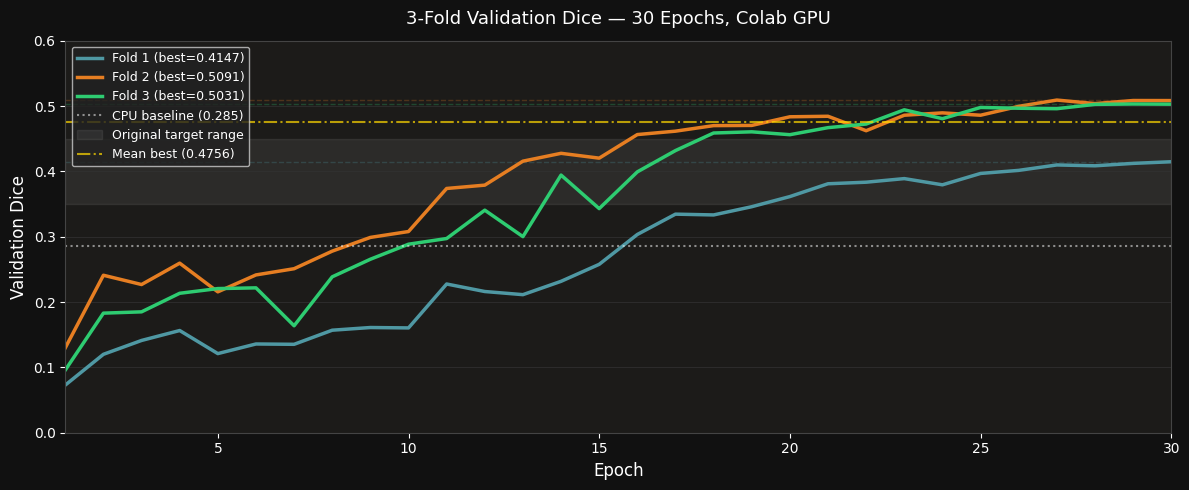

✅ Saved: /content/drive/MyDrive/MIA/ISLES_RESULTS/final_figures/graph1_training_curves.png


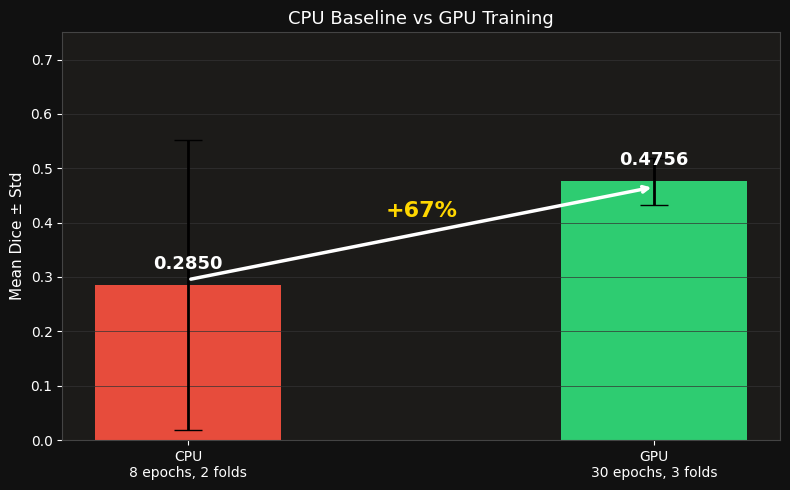

✅ Saved: /content/drive/MyDrive/MIA/ISLES_RESULTS/final_figures/graph2_cpu_vs_gpu.png


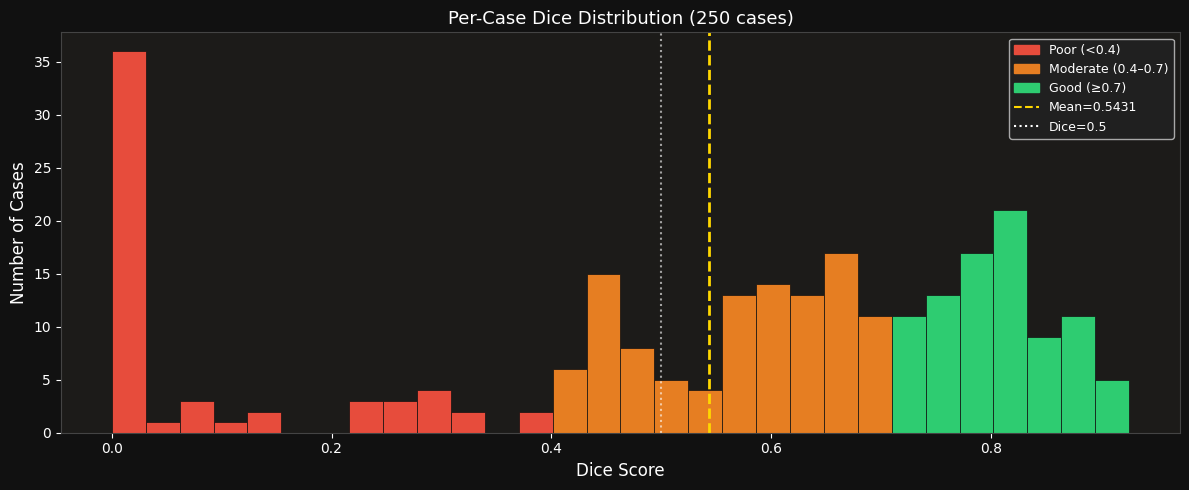

✅ Saved: /content/drive/MyDrive/MIA/ISLES_RESULTS/final_figures/graph3_dice_histogram.png
   Cases Dice≥0.7 : 91
   Cases Dice≥0.5 : 164
   Cases Dice<0.1 : 40

Loading models for visualization...
  ✅ 3 models loaded

Top 5 cases: ['sub-strokecase0066', 'sub-strokecase0246', 'sub-strokecase0161', 'sub-strokecase0221', 'sub-strokecase0047']

Visualizing sub-strokecase0066...


/tmp/ipykernel_756/116307863.py:270: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_756/116307863.py:270: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_756/116307863.py:272: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#111111")
/tmp/ipykernel_756/116307863.py:272: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#111111")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missi

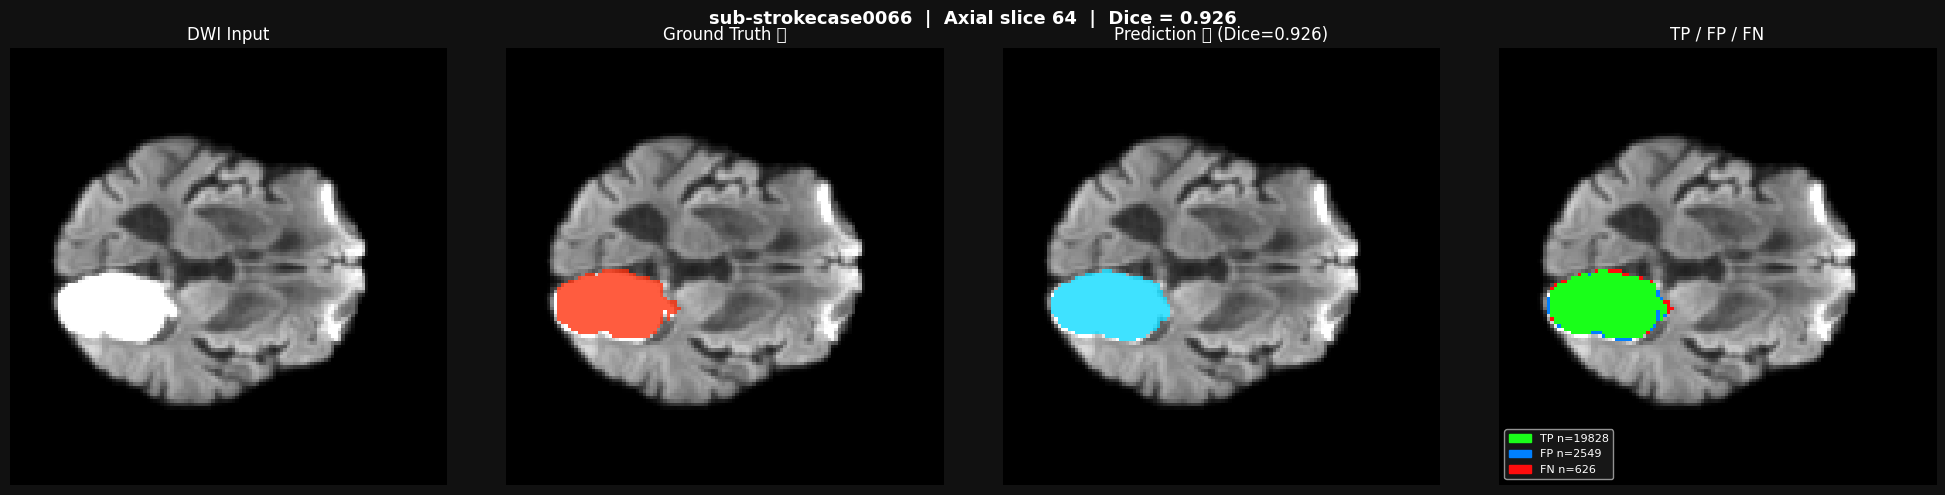

  ✅ Dice=0.926 saved

Visualizing sub-strokecase0246...


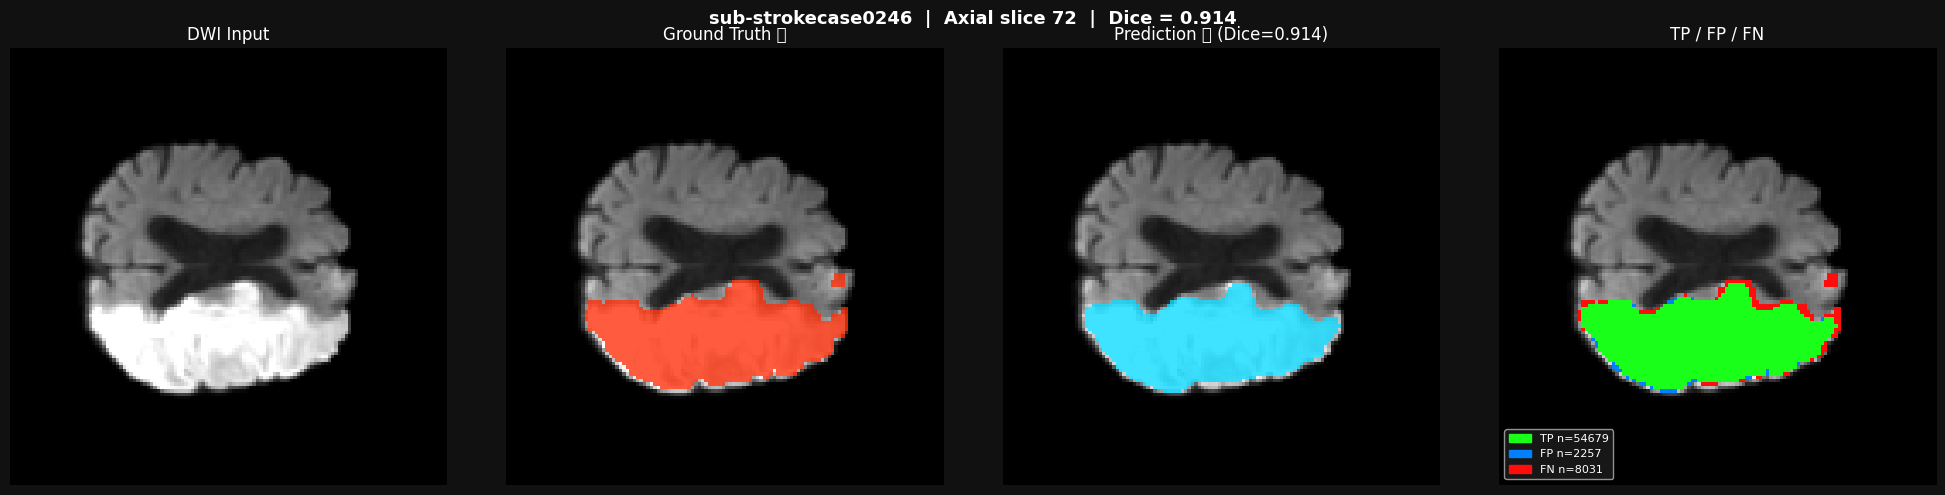

  ✅ Dice=0.914 saved

Visualizing sub-strokecase0161...


/tmp/ipykernel_756/116307863.py:270: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_756/116307863.py:270: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_756/116307863.py:272: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#111111")
/tmp/ipykernel_756/116307863.py:272: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#111111")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missi

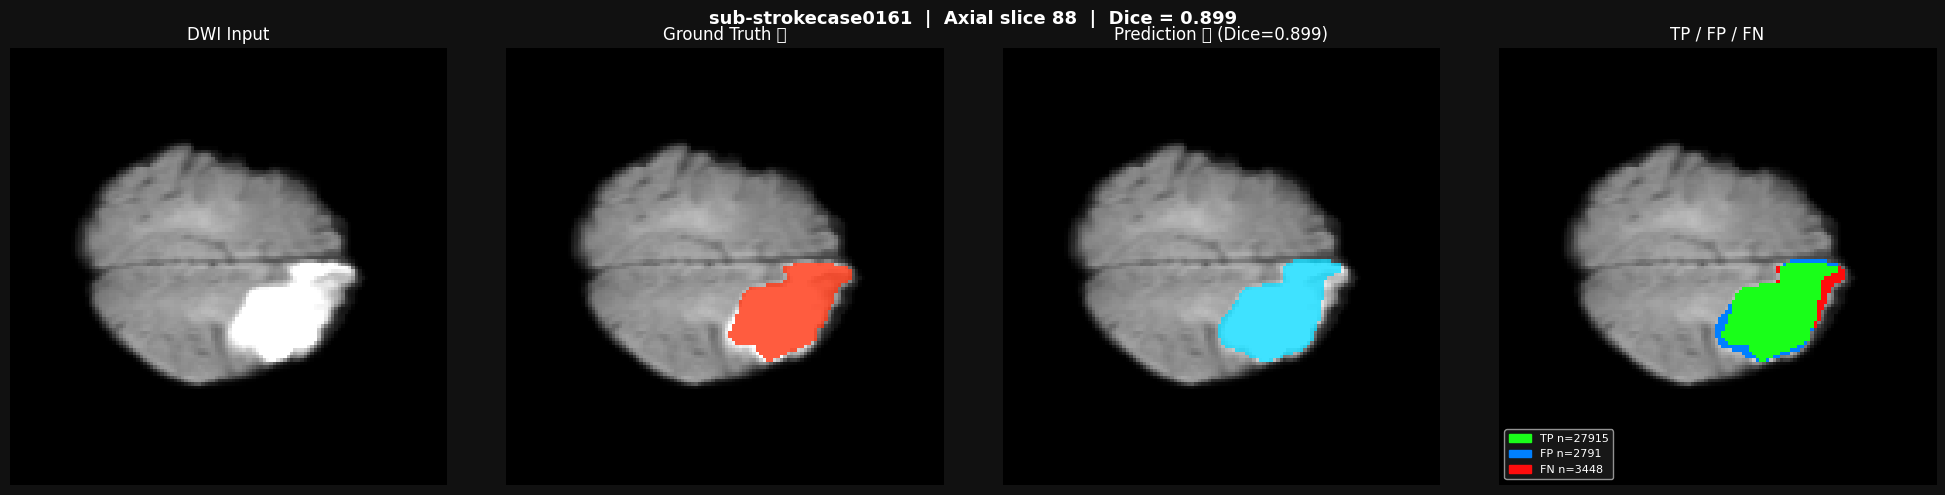

  ✅ Dice=0.899 saved

Visualizing sub-strokecase0221...


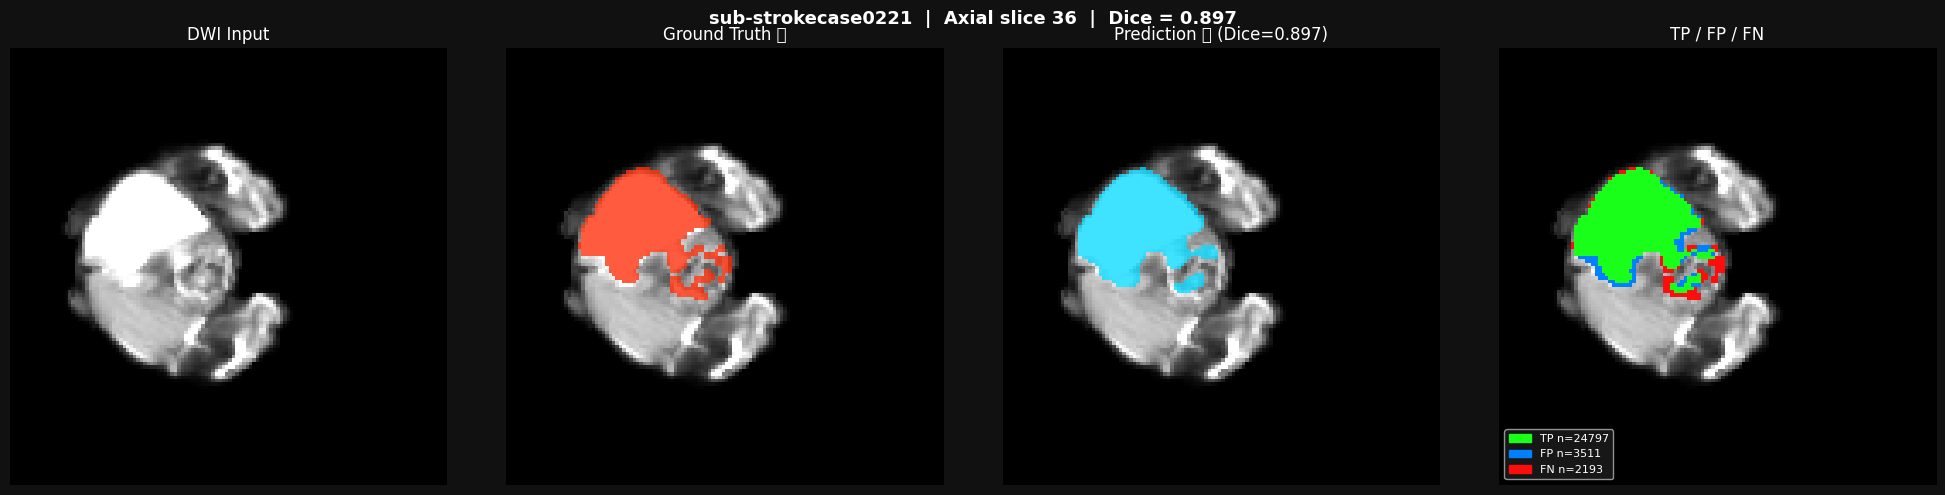

  ✅ Dice=0.897 saved

Visualizing sub-strokecase0047...


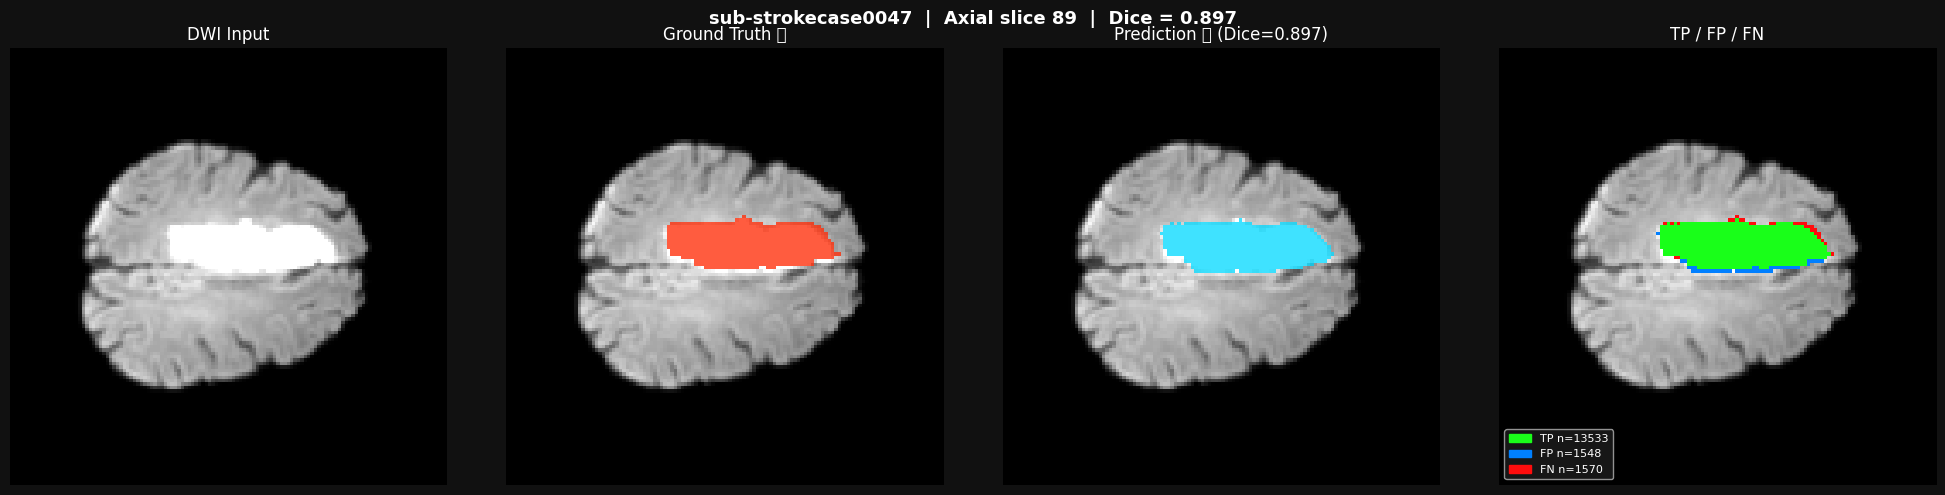

  ✅ Dice=0.897 saved

✅ All figures saved → /content/drive/MyDrive/MIA/ISLES_RESULTS/final_figures


In [11]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import nibabel as nib
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from monai.networks.nets import UNet

# ── paths ──────────────────────────────────────────────────────────
PREPROCESSED_ROOT = "/content/drive/MyDrive/MIA/7960856/ISLES-2022_preprocessed"
MASK_ROOT         = "/content/drive/MyDrive/MIA/7960856/ISLES-2022/derivatives"
OUTPUT_DIR        = "/content/drive/MyDrive/MIA/ISLES_RESULTS"
VIS_DIR           = os.path.join(OUTPUT_DIR, "final_figures")
os.makedirs(VIS_DIR, exist_ok=True)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD  = 0.5
TARGET_SIZE = (128, 128, 128)

# ── training history (your actual logs) ───────────────────────────
fold1_val = [0.0729,0.1200,0.1412,0.1564,0.1211,0.1358,0.1353,0.1569,0.1610,0.1604,
             0.2276,0.2161,0.2113,0.2317,0.2577,0.3034,0.3345,0.3333,0.3459,0.3614,
             0.3810,0.3834,0.3889,0.3794,0.3968,0.4015,0.4098,0.4085,0.4122,0.4147]
fold2_val = [0.1299,0.2410,0.2268,0.2595,0.2156,0.2415,0.2510,0.2779,0.2989,0.3079,
             0.3738,0.3789,0.4156,0.4276,0.4202,0.4563,0.4615,0.4700,0.4703,0.4835,
             0.4843,0.4622,0.4859,0.4895,0.4859,0.4995,0.5091,0.5037,0.5084,0.5083]
fold3_val = [0.0959,0.1830,0.1850,0.2134,0.2206,0.2217,0.1637,0.2386,0.2655,0.2885,
             0.2972,0.3406,0.3001,0.3943,0.3430,0.3992,0.4318,0.4587,0.4605,0.4561,
             0.4669,0.4724,0.4942,0.4806,0.4978,0.4966,0.4959,0.5025,0.5031,0.5028]
epochs = list(range(1, 31))
fold_best = [0.4147, 0.5091, 0.5031]
mean_dice = np.mean(fold_best)
std_dice  = np.std(fold_best)


# ══════════════════════════════════════════════════════════════════
# GRAPH 1 — Training Curves (all 3 folds)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5), facecolor="#111111")
colors = ["#4f98a3", "#e67e22", "#2ecc71"]
labels = [f"Fold 1 (best={fold_best[0]:.4f})",
          f"Fold 2 (best={fold_best[1]:.4f})",
          f"Fold 3 (best={fold_best[2]:.4f})"]
for data, color, label in zip([fold1_val, fold2_val, fold3_val], colors, labels):
    ax.plot(epochs, data, color=color, linewidth=2.5, label=label)
    ax.axhline(max(data), color=color, linestyle="--", alpha=0.25, linewidth=1)

ax.axhline(0.285, color="white", linestyle=":", linewidth=1.5, alpha=0.5, label="CPU baseline (0.285)")
ax.fill_between(epochs, 0.35, 0.45, alpha=0.07, color="white", label="Original target range")
ax.axhline(mean_dice, color="gold", linestyle="-.", linewidth=1.5,
           alpha=0.7, label=f"Mean best ({mean_dice:.4f})")

ax.set_facecolor("#1c1b19")
ax.set_xlabel("Epoch", color="white", fontsize=12)
ax.set_ylabel("Validation Dice", color="white", fontsize=12)
ax.set_title("3-Fold Validation Dice — 30 Epochs, Colab GPU", color="white", fontsize=13, pad=12)
ax.tick_params(colors="white")
ax.spines[:].set_color("#444")
ax.legend(fontsize=9, facecolor="#222", labelcolor="white", loc="upper left")
ax.set_ylim(0, 0.6); ax.set_xlim(1, 30)
ax.grid(axis="y", color="#333", linewidth=0.5)
plt.tight_layout()
path1 = os.path.join(VIS_DIR, "graph1_training_curves.png")
plt.savefig(path1, dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show(); print(f"✅ Saved: {path1}")


# ══════════════════════════════════════════════════════════════════
# GRAPH 2 — CPU vs GPU comparison bar chart
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5), facecolor="#111111")
labels2  = ["CPU\n8 epochs, 2 folds", "GPU\n30 epochs, 3 folds"]
values2  = [0.285, mean_dice]
stds2    = [0.267, std_dice]
bar_colors = ["#e74c3c", "#2ecc71"]

bars = ax.bar(labels2, values2, color=bar_colors, width=0.4,
              yerr=stds2, capsize=10, error_kw={"color":"white","linewidth":2})
for bar, val in zip(bars, values2):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.03,
            f"{val:.4f}", ha="center", color="white", fontsize=13, fontweight="bold")

ax.annotate("", xy=(1, mean_dice-0.01), xytext=(0, 0.285+0.01),
            arrowprops=dict(arrowstyle="->", color="white", lw=2.5))
ax.text(0.5, 0.41, f"+{((mean_dice-0.285)/0.285)*100:.0f}%",
        ha="center", color="gold", fontsize=16, fontweight="bold")

ax.set_facecolor("#1c1b19"); ax.set_ylim(0, 0.75)
ax.set_title("CPU Baseline vs GPU Training", color="white", fontsize=13)
ax.set_ylabel("Mean Dice ± Std", color="white", fontsize=11)
ax.tick_params(colors="white"); ax.spines[:].set_color("#444")
ax.grid(axis="y", color="#333", linewidth=0.5)
plt.tight_layout()
path2 = os.path.join(VIS_DIR, "graph2_cpu_vs_gpu.png")
plt.savefig(path2, dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show(); print(f"✅ Saved: {path2}")


# ══════════════════════════════════════════════════════════════════
# GRAPH 3 — Per-case Dice histogram (from eval_results_gpu.json)
# ══════════════════════════════════════════════════════════════════
eval_path = os.path.join(OUTPUT_DIR, "eval_results_gpu.json")
if os.path.exists(eval_path):
    with open(eval_path) as f:
        eval_data = json.load(f)

    dice_vals = [v["dice"] for v in eval_data["per_case"].values()]

    fig, ax = plt.subplots(figsize=(12, 5), facecolor="#111111")
    n, bins, patches_h = ax.hist(dice_vals, bins=30, color="#4f98a3", edgecolor="#111", linewidth=0.5)

    # Colour bars by performance zone
    for patch, left in zip(patches_h, bins[:-1]):
        if left >= 0.7:   patch.set_facecolor("#2ecc71")
        elif left >= 0.4: patch.set_facecolor("#e67e22")
        else:             patch.set_facecolor("#e74c3c")

    ax.axvline(np.mean(dice_vals), color="gold", linewidth=2,
               linestyle="--", label=f"Mean = {np.mean(dice_vals):.4f}")
    ax.axvline(0.5, color="white", linewidth=1.5,
               linestyle=":", alpha=0.6, label="Dice = 0.5 threshold")

    ax.set_facecolor("#1c1b19")
    ax.set_xlabel("Dice Score", color="white", fontsize=12)
    ax.set_ylabel("Number of Cases", color="white", fontsize=12)
    ax.set_title(f"Per-Case Dice Distribution ({len(dice_vals)} cases)",
                 color="white", fontsize=13)
    ax.tick_params(colors="white"); ax.spines[:].set_color("#444")
    ax.legend(fontsize=10, facecolor="#222", labelcolor="white")

    from matplotlib.patches import Patch
    legend2 = [Patch(color="#e74c3c", label="Poor (<0.4)"),
                Patch(color="#e67e22", label="Moderate (0.4–0.7)"),
                Patch(color="#2ecc71", label="Good (≥0.7)")]
    ax.legend(handles=legend2+[plt.Line2D([0],[0],color="gold",linestyle="--",label=f"Mean={np.mean(dice_vals):.4f}"),
                                plt.Line2D([0],[0],color="white",linestyle=":",label="Dice=0.5")],
              fontsize=9, facecolor="#222", labelcolor="white")

    plt.tight_layout()
    path3 = os.path.join(VIS_DIR, "graph3_dice_histogram.png")
    plt.savefig(path3, dpi=150, bbox_inches="tight", facecolor="#111111")
    plt.show(); print(f"✅ Saved: {path3}")
    print(f"   Cases Dice≥0.7 : {sum(1 for d in dice_vals if d>=0.7)}")
    print(f"   Cases Dice≥0.5 : {sum(1 for d in dice_vals if d>=0.5)}")
    print(f"   Cases Dice<0.1 : {sum(1 for d in dice_vals if d<0.1)}")
else:
    print("⚠ Run Cell 8 (evaluation) first to generate eval_results_gpu.json")


# ══════════════════════════════════════════════════════════════════
# VISUALIZATIONS — Top 5 best Dice cases
# ══════════════════════════════════════════════════════════════════
def build_model():
    return UNet(spatial_dims=3, in_channels=3, out_channels=1,
                channels=(32,64,128,256), strides=(2,2,2),
                num_res_units=2).to(device)

def load_preprocessed_case(case_id):
    folder = f"{case_id}_ses-0001_dwi"
    img = nib.load(os.path.join(PREPROCESSED_ROOT, folder, f"{folder}_img.nii.gz")).get_fdata()
    img = np.transpose(img,(3,0,1,2)) if img.ndim==4 else np.expand_dims(img,0)
    img = torch.tensor(img[:3].astype(np.float32))
    return F.interpolate(img.unsqueeze(0),size=TARGET_SIZE,
                         mode="trilinear",align_corners=False).squeeze(0)

def load_gt_mask(case_id):
    mask = nib.load(os.path.join(MASK_ROOT,case_id,"ses-0001",
                                 f"{case_id}_ses-0001_msk.nii.gz")).get_fdata().astype(np.float32)
    mask = torch.tensor(np.expand_dims(mask,0))
    return F.interpolate(mask.unsqueeze(0),size=TARGET_SIZE,mode="nearest").squeeze(0).numpy()

def normalize(a):
    return (a-a.min())/(a.max()-a.min()+1e-8)

def get_best_slice(m):
    s = m.sum(axis=(0,1))
    return int(np.argmax(s)) if s.max()>0 else m.shape[2]//2

model_paths = [os.path.join(OUTPUT_DIR,f"fold{i}_best.pt") for i in [1,2,3]]
print("\nLoading models for visualization...")
models = []
for path in model_paths:
    if not os.path.exists(path): print(f"  ⚠ Missing: {path}"); continue
    m = build_model()
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval(); models.append(m)
print(f"  ✅ {len(models)} models loaded")

# Pick top 5 cases by eval Dice, fallback to hardcoded if json missing
if os.path.exists(eval_path):
    sorted_cases = sorted(eval_data["per_case"].items(),
                          key=lambda x: x[1]["dice"], reverse=True)
    vis_cases = [c for c,_ in sorted_cases[:5]]
    print(f"\nTop 5 cases: {vis_cases}")
else:
    vis_cases = ["sub-strokecase0066","sub-strokecase0047",
                 "sub-strokecase0221","sub-strokecase0031","sub-strokecase0078"]
    print("⚠ Using fallback case list")

GT_COLOR   = np.array([1.0, 0.15, 0.0])
PRED_COLOR = np.array([0.0, 0.85, 1.0])
TP_COLOR   = np.array([0.1, 1.0,  0.1])
FP_COLOR   = np.array([0.0, 0.5,  1.0])
FN_COLOR   = np.array([1.0, 0.05, 0.05])
ALPHA      = 0.75

for cid in vis_cases:
    print(f"\nVisualizing {cid}...")
    try:
        img    = load_preprocessed_case(cid)
        img_in = img.unsqueeze(0).to(device)
        gt     = load_gt_mask(cid)[0]

        probs = []
        with torch.no_grad():
            for m in models:
                probs.append(torch.sigmoid(m(img_in))[0,0].cpu().numpy())

        prob_ens = np.mean(probs, axis=0)
        pred_bin = (prob_ens > THRESHOLD).astype(np.float32)

        tp = int(((pred_bin==1)&(gt==1)).sum())
        fp = int(((pred_bin==1)&(gt==0)).sum())
        fn = int(((pred_bin==0)&(gt==1)).sum())
        dice = 2*tp / (2*tp+fp+fn+1e-5)

        dwi = normalize(img[0].numpy())
        sl  = get_best_slice(gt)

        fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor="#111111")
        fig.suptitle(f"{cid}  |  Axial slice {sl}  |  Dice = {dice:.3f}",
                     fontsize=13, fontweight="bold", color="white")

        axes[0].imshow(dwi[:,:,sl], cmap="gray", origin="lower")
        axes[0].set_title("DWI Input", color="white", fontsize=12)
        axes[0].axis("off")

        bg = np.stack([dwi[:,:,sl]]*3, axis=-1)
        rgb = bg.copy()
        rgb[gt[:,:,sl]>0] = (1-ALPHA)*bg[gt[:,:,sl]>0] + ALPHA*GT_COLOR
        axes[1].imshow(rgb, origin="lower")
        axes[1].set_title("Ground Truth 🔴", color="white", fontsize=12)
        axes[1].axis("off")

        bg = np.stack([dwi[:,:,sl]]*3, axis=-1)
        rgb = bg.copy()
        rgb[pred_bin[:,:,sl]>0] = (1-ALPHA)*bg[pred_bin[:,:,sl]>0] + ALPHA*PRED_COLOR
        axes[2].imshow(rgb, origin="lower")
        axes[2].set_title(f"Prediction 🔵 (Dice={dice:.3f})", color="white", fontsize=12)
        axes[2].axis("off")

        bg  = np.stack([normalize(dwi[:,:,sl])]*3, axis=-1)
        rgb4 = bg.copy()
        gt_s = gt[:,:,sl]; pred_s = pred_bin[:,:,sl]
        rgb4[(pred_s==1)&(gt_s==1)] = TP_COLOR
        rgb4[(pred_s==1)&(gt_s==0)] = FP_COLOR
        rgb4[(pred_s==0)&(gt_s==1)] = FN_COLOR
        axes[3].imshow(rgb4, origin="lower")
        axes[3].legend(handles=[
            mpatches.Patch(color=TP_COLOR, label=f"TP n={tp}"),
            mpatches.Patch(color=FP_COLOR, label=f"FP n={fp}"),
            mpatches.Patch(color=FN_COLOR, label=f"FN n={fn}"),
        ], loc="lower left", fontsize=8, framealpha=0.7,
           facecolor="#222", labelcolor="white")
        axes[3].set_title("TP / FP / FN", color="white", fontsize=12)
        axes[3].axis("off")

        plt.tight_layout()
        save_path = os.path.join(VIS_DIR, f"{cid}_vis.png")
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#111111")
        plt.show()
        print(f"  ✅ Dice={dice:.3f} saved")

    except Exception as e:
        print(f"  ❌ {e}")

print(f"\n✅ All figures saved → {VIS_DIR}")

✅ 3 models loaded

Classifying cases by DWI/FLAIR signal ratio...
  Hyper-acute : 79 | Acute : 79 | Subacute : 79

Representative cases:
  ⚡ Hyper-Acute → sub-strokecase0066
  🔴 Acute → sub-strokecase0047
  🟡 Subacute → sub-strokecase0161
  ✅ Row 1 ⚡ Hyper-Acute — Dice=0.926  Vol=20454vx
  ✅ Row 2 🔴 Acute — Dice=0.897  Vol=15103vx
  ✅ Row 3 🟡 Subacute — Dice=0.899  Vol=31363vx


/tmp/ipykernel_756/651017462.py:201: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0.1, 0, 1, 0.97])
/tmp/ipykernel_756/651017462.py:201: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0.1, 0, 1, 0.97])
/tmp/ipykernel_756/651017462.py:203: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#111111")
/tmp/ipykernel_756/651017462.py:203: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#111111")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning

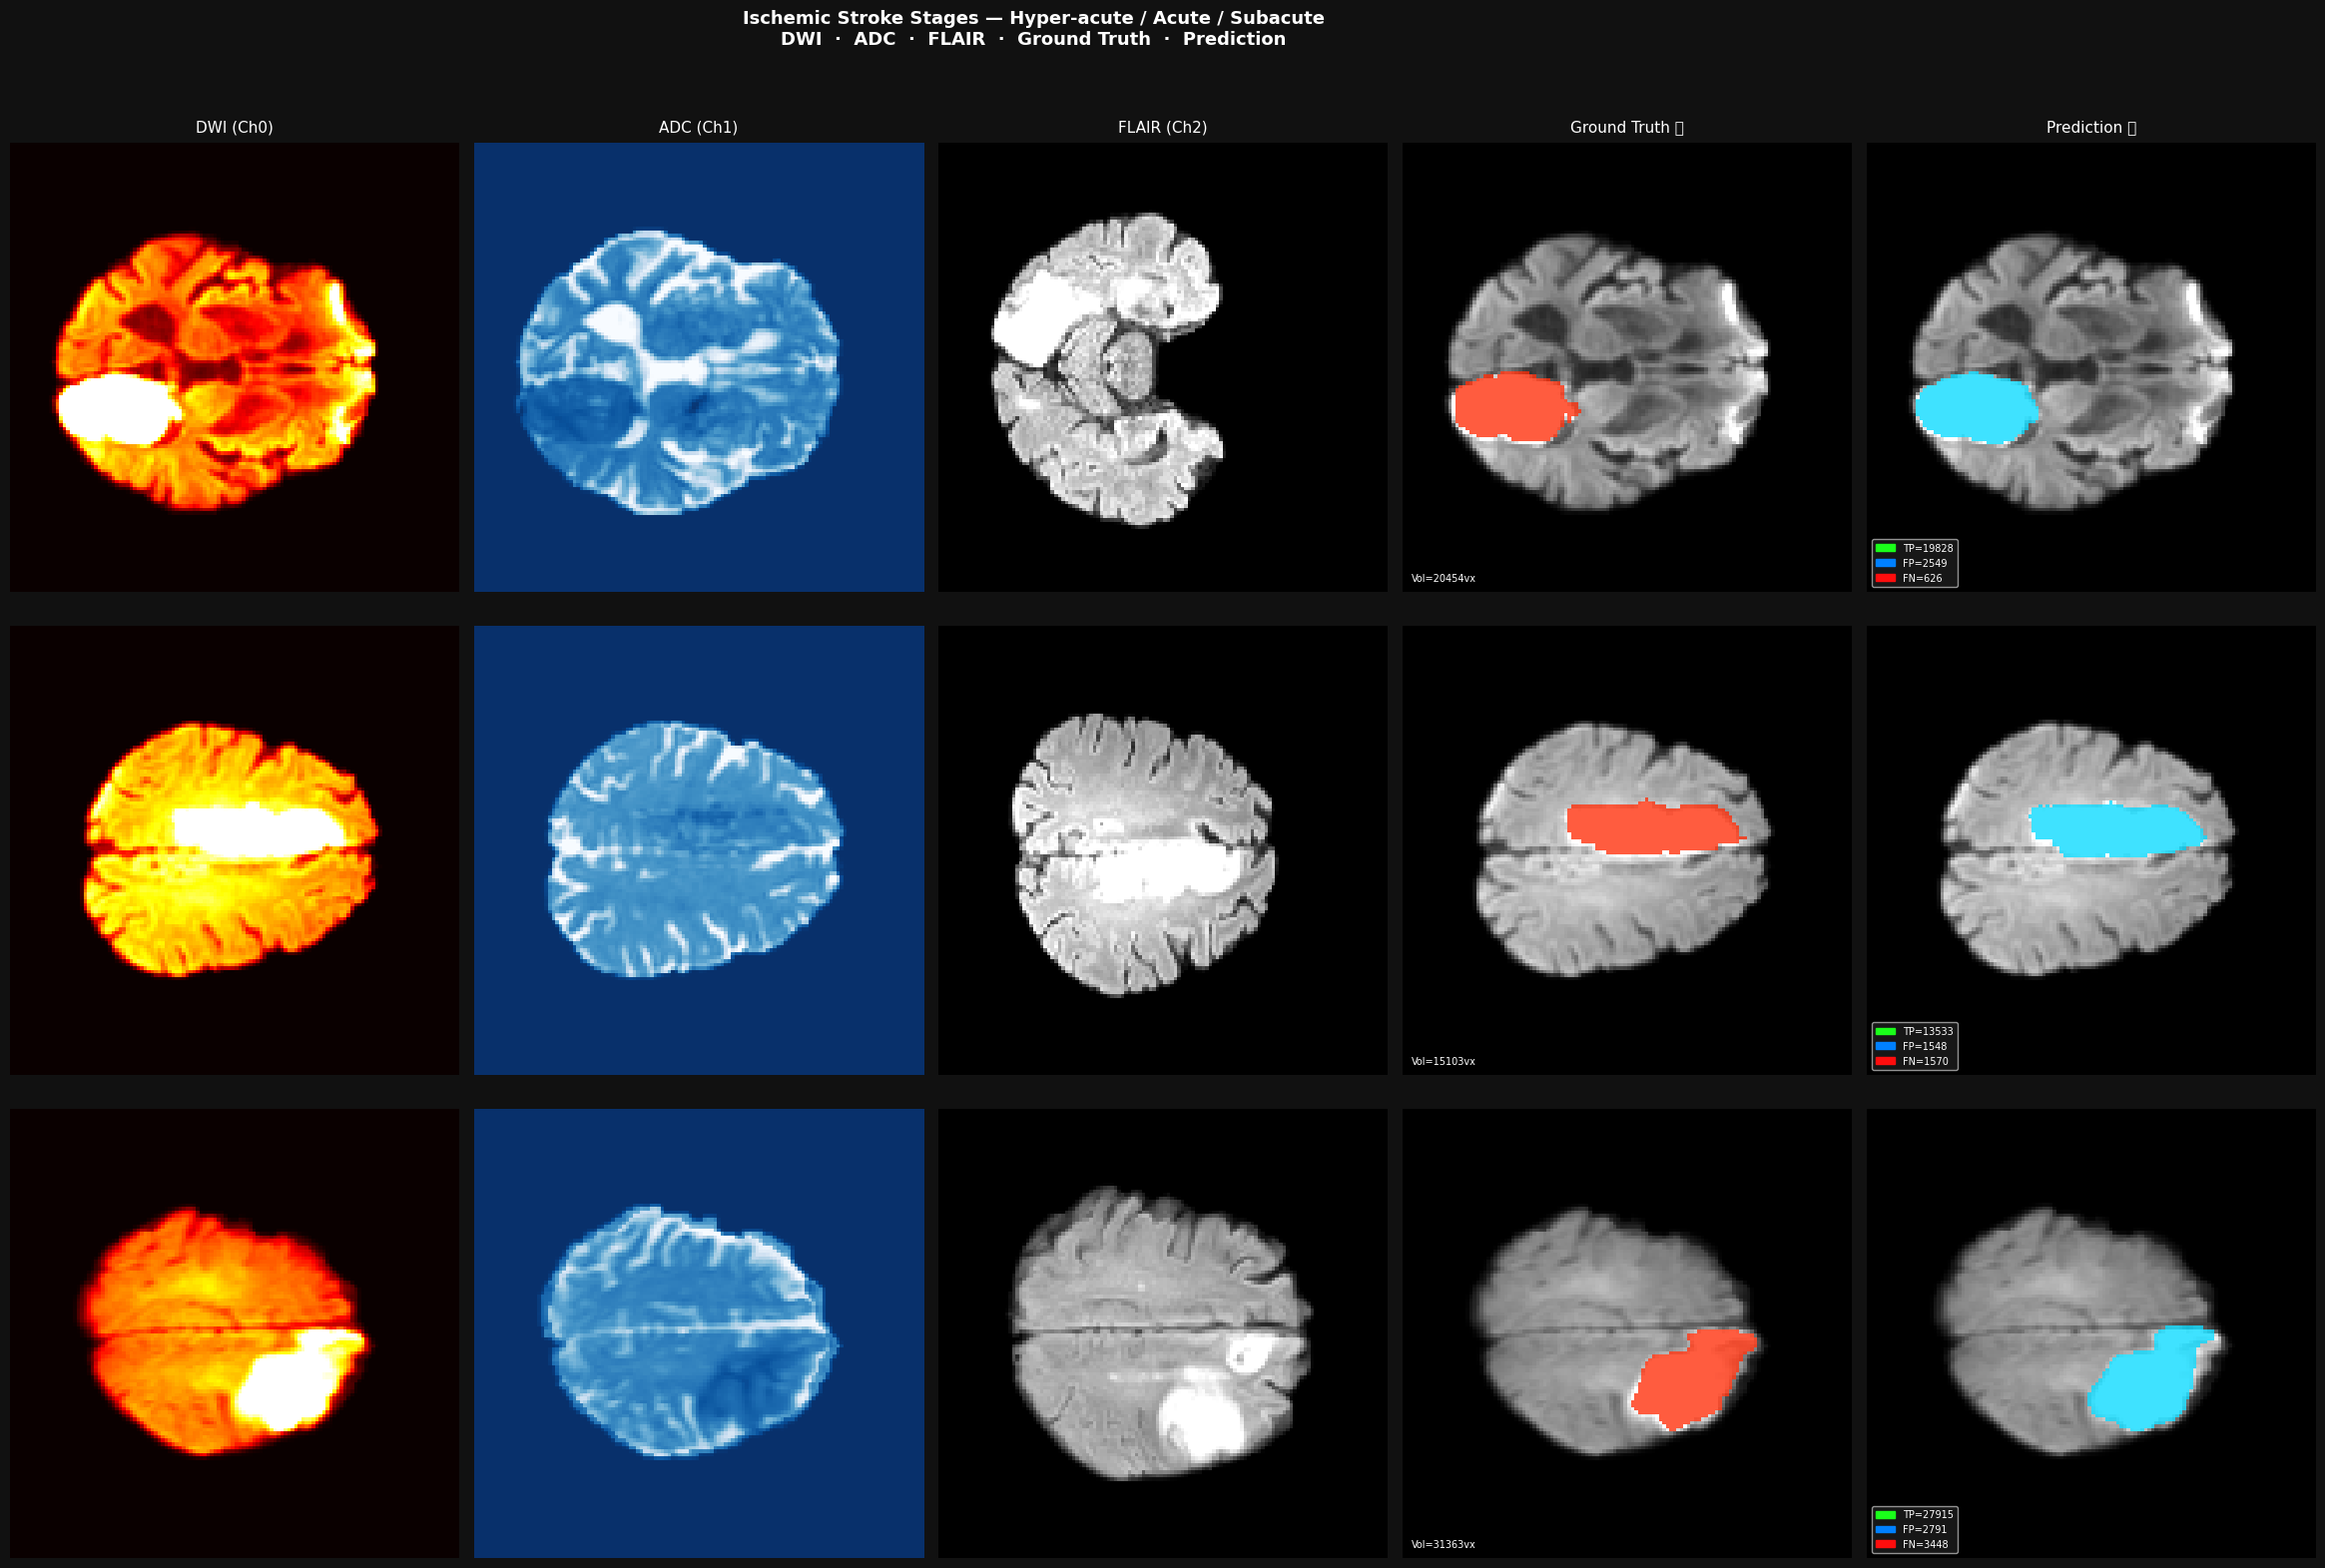


✅ Saved → /content/drive/MyDrive/MIA/ISLES_RESULTS/final_figures/stroke_stages_comparison.png


In [15]:
import os, json
import numpy as np
import torch
import torch.nn.functional as F
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from monai.networks.nets import UNet

# ── paths ──────────────────────────────────────────────────────────
PREPROCESSED_ROOT = "/content/drive/MyDrive/MIA/7960856/ISLES-2022_preprocessed"
MASK_ROOT         = "/content/drive/MyDrive/MIA/7960856/ISLES-2022/derivatives"
OUTPUT_DIR        = "/content/drive/MyDrive/MIA/ISLES_RESULTS"
VIS_DIR           = os.path.join(OUTPUT_DIR, "final_figures")
os.makedirs(VIS_DIR, exist_ok=True)

device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD   = 0.5
TARGET_SIZE = (128, 128, 128)

# ── helpers ────────────────────────────────────────────────────────
def normalize(a):
    p1, p99 = np.percentile(a, 1), np.percentile(a, 99)
    return (np.clip(a, p1, p99) - p1) / (p99 - p1 + 1e-8)

def get_best_slice(m):
    s = m.sum(axis=(0, 1))
    return int(np.argmax(s)) if s.max() > 0 else m.shape[2] // 2

def load_preprocessed_case(case_id):
    folder = f"{case_id}_ses-0001_dwi"
    img = nib.load(os.path.join(PREPROCESSED_ROOT, folder,
                                f"{folder}_img.nii.gz")).get_fdata()
    img = np.transpose(img,(3,0,1,2)) if img.ndim==4 else np.expand_dims(img,0)
    img = torch.tensor(img[:3].astype(np.float32))
    return F.interpolate(img.unsqueeze(0), size=TARGET_SIZE,
                         mode="trilinear", align_corners=False).squeeze(0)

def load_gt_mask(case_id):
    mask = nib.load(os.path.join(MASK_ROOT, case_id, "ses-0001",
                    f"{case_id}_ses-0001_msk.nii.gz")).get_fdata().astype(np.float32)
    mask = torch.tensor(np.expand_dims(mask, 0))
    return F.interpolate(mask.unsqueeze(0), size=TARGET_SIZE,
                         mode="nearest").squeeze(0).numpy()

def build_model():
    return UNet(spatial_dims=3, in_channels=3, out_channels=1,
                channels=(32, 64, 128, 256), strides=(2, 2, 2),
                num_res_units=2).to(device)

# ── load models ────────────────────────────────────────────────────
models = []
for i in [1, 2, 3]:
    path = os.path.join(OUTPUT_DIR, f"fold{i}_best.pt")
    if not os.path.exists(path):
        print(f"  ⚠ Missing: {path}"); continue
    m = build_model()
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval(); models.append(m)
print(f"✅ {len(models)} models loaded")

# ── classify all cases by DWI/FLAIR ratio ─────────────────────────
print("\nClassifying cases by DWI/FLAIR signal ratio...")
all_cases = sorted([
    f.replace("_ses-0001_dwi","")
    for f in os.listdir(PREPROCESSED_ROOT)
    if f.endswith("_ses-0001_dwi")
])

ratios = {}
for cid in all_cases:
    try:
        img = load_preprocessed_case(cid)
        gt  = load_gt_mask(cid)[0]
        if gt.sum() < 50: continue
        dwi_in_lesion   = img[0].numpy()[gt > 0].mean()
        flair_in_lesion = img[2].numpy()[gt > 0].mean()
        ratios[cid] = dwi_in_lesion / (flair_in_lesion + 1e-8)
    except: pass

sorted_by_ratio = sorted(ratios.items(), key=lambda x: x[1], reverse=True)
n = len(sorted_by_ratio)
hyper_acute = [c for c,_ in sorted_by_ratio[:n//3]]
acute       = [c for c,_ in sorted_by_ratio[n//3:2*n//3]]
subacute    = [c for c,_ in sorted_by_ratio[2*n//3:]]
print(f"  Hyper-acute : {len(hyper_acute)} | Acute : {len(acute)} | Subacute : {len(subacute)}")

# ── pick best Dice representative per group ────────────────────────
eval_path = os.path.join(OUTPUT_DIR, "eval_results_gpu.json")
def pick_rep(group):
    if os.path.exists(eval_path):
        with open(eval_path) as f:
            ed = json.load(f)["per_case"]
        scored = [(c, ed[c]["dice"]) for c in group if c in ed]
        if scored: return max(scored, key=lambda x: x[1])[0]
    return group[len(group)//2] if group else None

rep_hyper    = pick_rep(hyper_acute)
rep_acute    = pick_rep(acute)
rep_subacute = pick_rep(subacute)

groups = [
    (rep_hyper,    "⚡ Hyper-Acute\n(<4.5 hrs)\nDWI+  FLAIR−"),
    (rep_acute,    "🔴 Acute\n(0–7 days)\nDWI+  FLAIR+"),
    (rep_subacute, "🟡 Subacute\n(1–3 weeks)\nDWI fading  FLAIR+"),
]
print("\nRepresentative cases:")
for cid, lbl in groups:
    if cid: print(f"  {lbl.split(chr(10))[0]} → {cid}")

# ── colours ────────────────────────────────────────────────────────
GT_COLOR   = np.array([1.0, 0.15, 0.0])
PRED_COLOR = np.array([0.0, 0.85, 1.0])
TP_COLOR   = np.array([0.1, 1.0,  0.1])
FP_COLOR   = np.array([0.0, 0.5,  1.0])
FN_COLOR   = np.array([1.0, 0.05, 0.05])
ALPHA      = 0.75

# ── 3×5 figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(26, 16), facecolor="#111111")
fig.suptitle(
    "Ischemic Stroke Stages — Hyper-acute / Acute / Subacute\n"
    "DWI  ·  ADC  ·  FLAIR  ·  Ground Truth  ·  Prediction",
    fontsize=13, fontweight="bold", color="white", y=0.99)

for col, title in enumerate(["DWI (Ch0)", "ADC (Ch1)", "FLAIR (Ch2)",
                               "Ground Truth 🔴", "Prediction 🔵"]):
    axes[0][col].set_title(title, color="white", fontsize=11, pad=8)

for row, (cid, group_label) in enumerate(groups):
    if cid is None:
        for col in range(5): axes[row][col].axis("off")
        continue
    try:
        img    = load_preprocessed_case(cid)
        img_in = img.unsqueeze(0).to(device)
        gt     = load_gt_mask(cid)[0]

        probs = []
        with torch.no_grad():
            for m in models:
                probs.append(torch.sigmoid(m(img_in))[0,0].cpu().numpy())
        prob_ens = np.mean(probs, axis=0)
        pred_bin = (prob_ens > THRESHOLD).astype(np.float32)

        tp   = int(((pred_bin==1)&(gt==1)).sum())
        fp   = int(((pred_bin==1)&(gt==0)).sum())
        fn   = int(((pred_bin==0)&(gt==1)).sum())
        dice = 2*tp / (2*tp+fp+fn+1e-5)
        sl   = get_best_slice(gt)

        axes[row][0].set_ylabel(
            f"{group_label}\n{cid}\nDice={dice:.3f}",
            color="white", fontsize=8, rotation=0,
            labelpad=130, va="center")

        # DWI — hot colormap (bright lesion pops)
        axes[row][0].imshow(normalize(img[0].numpy())[:,:,sl],
                            cmap="hot", origin="lower")
        axes[row][0].axis("off")

        # ADC — inverted blues (lesion is dark on ADC)
        axes[row][1].imshow(normalize(img[1].numpy())[:,:,sl],
                            cmap="Blues_r", origin="lower")
        axes[row][1].axis("off")

        # FLAIR — gray
        axes[row][2].imshow(normalize(img[2].numpy())[:,:,sl],
                            cmap="gray", origin="lower")
        axes[row][2].axis("off")

        # Ground Truth overlay on DWI
        dwi = normalize(img[0].numpy())
        bg  = np.stack([dwi[:,:,sl]]*3, axis=-1)
        rgb = bg.copy()
        rgb[gt[:,:,sl]>0] = (1-ALPHA)*bg[gt[:,:,sl]>0] + ALPHA*GT_COLOR
        axes[row][3].imshow(rgb, origin="lower")
        axes[row][3].text(2, 2, f"Vol={int(gt.sum())}vx",
                          color="white", fontsize=7, va="bottom")
        axes[row][3].axis("off")

        # Prediction overlay on DWI
        bg  = np.stack([dwi[:,:,sl]]*3, axis=-1)
        rgb = bg.copy()
        rgb[pred_bin[:,:,sl]>0] = (1-ALPHA)*bg[pred_bin[:,:,sl]>0] + ALPHA*PRED_COLOR
        axes[row][4].imshow(rgb, origin="lower")
        axes[row][4].legend(handles=[
            mpatches.Patch(color=TP_COLOR, label=f"TP={tp}"),
            mpatches.Patch(color=FP_COLOR, label=f"FP={fp}"),
            mpatches.Patch(color=FN_COLOR, label=f"FN={fn}"),
        ], loc="lower left", fontsize=7, framealpha=0.7,
           facecolor="#222", labelcolor="white")
        axes[row][4].axis("off")

        print(f"  ✅ Row {row+1} {group_label.split(chr(10))[0]} — Dice={dice:.3f}  Vol={int(gt.sum())}vx")

    except Exception as e:
        print(f"  ❌ Row {row+1}: {e}")
        for col in range(5): axes[row][col].axis("off")

plt.tight_layout(rect=[0.1, 0, 1, 0.97])
save_path = os.path.join(VIS_DIR, "stroke_stages_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#111111")
plt.show()
print(f"\n✅ Saved → {save_path}")